In [1]:
"""
=============================================================
  Pipeline de Integración de Datos
=============================================================
  Fuentes:
    1. Producción_café.xlsx                      → producción mensual Caldas
    2. df_chirps_mensual_caldas_cauca__1_.csv     → precipitación CHIRPS
    3. ndvi_modis16_caldas_cauca_monthly_v2.csv   → índice NDVI MODIS
    4. Precios_saco_cafe_.xlsx                    → precio interno mensual

  Variables: solo variables originales de cada fuente + fecha
  Cobertura objetivo: 2002–2025 (Caldas)
  Llave de integración: year + month
=============================================================
"""

import os
import pandas as pd
import warnings
warnings.filterwarnings("ignore")

# ─────────────────────────────────────────────
# RUTAS DE ARCHIVOS
# Ajusta estas rutas según tu entorno:
#   Colab  → "/content/nombre_archivo.xlsx"
#   Local  → "nombre_archivo.xlsx"  (si está en la misma carpeta)
# ─────────────────────────────────────────────
PATH_PRODUCCION = "Producción_café.xlsx"
PATH_CHIRPS     = "df_chirps_mensual_caldas_cauca (1).csv"
PATH_NDVI       = "ndvi_modis16_caldas_cauca_monthly_v3.csv"
PATH_PRECIOS    = "Precios_saco_cafe).xlsx"

DEPTO_OBJETIVO  = "Caldas"
ANIO_INICIO     = 2002
ANIO_FIN        = 2025


# ─────────────────────────────────────────────
# 1. PRODUCCIÓN MENSUAL — CALDAS
# ─────────────────────────────────────────────
def cargar_produccion(path: str) -> pd.DataFrame:
    """
    Variables originales retenidas:
      - prod_caldas_miles_sacos   : producción mensual Caldas (miles de sacos 60kg)
      - prod_nacional_miles_sacos : producción mensual Colombia
    """
    df = pd.read_excel(path)

    df.columns = [
        "fecha_raw", "year", "fecha_raw2", "month",
        "produccion_nacional", "pct_nacional", "produccion_caldas"
    ]

    df["year"]  = pd.to_numeric(df["year"],  errors="coerce").astype("Int64")
    df["month"] = pd.to_numeric(df["month"], errors="coerce").astype("Int64")

    # Solo filas donde Caldas tiene dato
    df = df[df["produccion_caldas"].notna()].copy()

    df = df[["year", "month", "produccion_caldas", "produccion_nacional"]].copy()
    df = df.rename(columns={
        "produccion_caldas":   "prod_caldas_miles_sacos",
        "produccion_nacional": "prod_nacional_miles_sacos"
    })

    df = df.sort_values(["year", "month"]).reset_index(drop=True)
    print(f"[Producción]  Filas: {len(df)} | Rango: {df.year.min()}–{df.year.max()}")
    return df


# ─────────────────────────────────────────────
# 2. PRECIPITACIÓN CHIRPS
# ─────────────────────────────────────────────
def cargar_chirps(path: str, depto: str = DEPTO_OBJETIVO) -> pd.DataFrame:
    """
    Variables originales retenidas:
      - precip_mm : precipitación mensual acumulada (mm) — fuente CHIRPS satelital
    """
    df = pd.read_csv(path)

    df = df[df["departamento"].str.strip() == depto].copy()
    df = df.rename(columns={"chirps_precip_mm": "precip_mm"})
    df = df[["year", "month", "precip_mm"]].copy()

    df["year"]  = df["year"].astype("Int64")
    df["month"] = df["month"].astype("Int64")

    df = df.sort_values(["year", "month"]).reset_index(drop=True)
    print(f"[CHIRPS]      Filas: {len(df)} | Rango: {df.year.min()}–{df.year.max()} | Depto: {depto}")
    return df


# ─────────────────────────────────────────────
# 3. NDVI MODIS
# ─────────────────────────────────────────────
def cargar_ndvi(path: str, depto: str = DEPTO_OBJETIVO) -> pd.DataFrame:
    """
    Variables originales retenidas:
      - ndvi_mean   : media del NDVI mensual departamental
      - ndvi_median : mediana del NDVI mensual departamental
      - ndvi_p90    : percentil 90 del NDVI (zonas con mayor vigor vegetal)
    Nota: cobertura 2016–2025 → NaN para 2002–2015
    """
    df = pd.read_csv(path)

    df = df[df["depto"].str.strip() == depto].copy()
    df = df[["year", "month", "ndvi_mean", "ndvi_median", "ndvi_p90"]].copy()

    df["year"]  = df["year"].astype("Int64")
    df["month"] = df["month"].astype("Int64")

    df = df.sort_values(["year", "month"]).reset_index(drop=True)
    print(f"[NDVI]        Filas: {len(df)} | Rango: {df.year.min()}–{df.year.max()} | Depto: {depto}")
    return df


# ─────────────────────────────────────────────
# 4. PRECIOS INTERNOS
# ─────────────────────────────────────────────
def cargar_precios(path: str) -> pd.DataFrame:
    """
    Variables originales retenidas:
      - precio_interno_cop : precio interno mensual del saco de café (pesos colombianos)
    """
    df = pd.read_excel(path)
    df.columns = ["fecha", "precio_interno_cop"]

    df["fecha"] = pd.to_datetime(df["fecha"], errors="coerce")
    df = df[df["fecha"].notna()].copy()

    df["year"]  = df["fecha"].dt.year.astype("Int64")
    df["month"] = df["fecha"].dt.month.astype("Int64")

    df = df[["year", "month", "precio_interno_cop"]].copy()
    df = df.sort_values(["year", "month"]).reset_index(drop=True)

    print(f"[Precios]     Filas: {len(df)} | Rango: {df.year.min()}–{df.year.max()}")
    return df


# ─────────────────────────────────────────────
# 5. PIPELINE PRINCIPAL DE INTEGRACIÓN
# ─────────────────────────────────────────────
def integrar_fuentes(
    anio_inicio: int = ANIO_INICIO,
    anio_fin:    int = ANIO_FIN
) -> pd.DataFrame:
    """
    Une las cuatro fuentes por year + month (LEFT JOIN sobre producción).
    Retorna el DataFrame maestro con variables originales únicamente.
    """
    print("=" * 55)
    print("  CAFÉ SEGURO — Integración de Fuentes de Datos")
    print("=" * 55)

    # Cargar fuentes
    df_prod    = cargar_produccion(PATH_PRODUCCION)
    df_chirps  = cargar_chirps(PATH_CHIRPS)
    df_ndvi    = cargar_ndvi(PATH_NDVI)
    df_precios = cargar_precios(PATH_PRECIOS)

    # Base: producción Caldas (ancla temporal del dataset)
    df_master = df_prod.copy()

    # LEFT JOIN — CHIRPS
    df_master = df_master.merge(
        df_chirps[["year", "month", "precip_mm"]],
        on=["year", "month"], how="left"
    )

    # LEFT JOIN — NDVI (NaN esperado para 2002–2015)
    df_master = df_master.merge(
        df_ndvi[["year", "month", "ndvi_mean", "ndvi_median", "ndvi_p90"]],
        on=["year", "month"], how="left"
    )

    # LEFT JOIN — Precios
    df_master = df_master.merge(
        df_precios[["year", "month", "precio_interno_cop"]],
        on=["year", "month"], how="left"
    )

    # Filtrar ventana objetivo
    df_master = df_master[
        (df_master["year"] >= anio_inicio) &
        (df_master["year"] <= anio_fin)
    ].copy()

    df_master = df_master.sort_values(["year", "month"]).reset_index(drop=True)

    # Columna fecha datetime (única variable construida, necesaria como índice temporal)
    df_master["fecha"] = pd.to_datetime(
        df_master[["year", "month"]].assign(day=1)
    )

    # Orden final de columnas
    cols_orden = [
        "fecha", "year", "month",
        "prod_caldas_miles_sacos", "prod_nacional_miles_sacos",
        "precip_mm",
        "ndvi_mean", "ndvi_median", "ndvi_p90",
        "precio_interno_cop"
    ]
    df_master = df_master[cols_orden]

    return df_master


# ─────────────────────────────────────────────
# 6. DIAGNÓSTICO
# ─────────────────────────────────────────────
def diagnostico(df: pd.DataFrame) -> None:
    print("\n" + "=" * 55)
    print("  DIAGNÓSTICO DEL DATASET MAESTRO")
    print("=" * 55)
    print(f"  Filas totales    : {len(df)}")
    print(f"  Columnas         : {len(df.columns)}")
    print(f"  Período cubierto : {df.year.min()} – {df.year.max()}")
    print(f"  Meses con NDVI   : {df['ndvi_mean'].notna().sum()} "
          f"({df['ndvi_mean'].notna().sum()/len(df)*100:.0f}%)")

    print("\n  Nulos por columna:")
    nulos = df.isnull().sum()
    nulos = nulos[nulos > 0]
    if len(nulos) == 0:
        print("    Sin nulos.")
    for col, n in nulos.items():
        print(f"    {col:<30} {n:>4} ({n/len(df)*100:.1f}%)")

    print("\n  Estadísticas descriptivas:")
    print(df.drop(columns=["fecha"]).describe().round(2).to_string())


# ─────────────────────────────────────────────
# 7. EJECUCIÓN
# ─────────────────────────────────────────────
if __name__ == "__main__":

    df_cafe = integrar_fuentes(anio_inicio=2002, anio_fin=2025)

    diagnostico(df_cafe)

    print("\n  Primeras filas:")
    print(df_cafe.head(6).to_string(index=False))

    print("\n  Últimas filas:")
    print(df_cafe.tail(6).to_string(index=False))

    # Exportar CSV
    output_path = "cafe_seguro_master.csv"
    os.makedirs(os.path.dirname(output_path), exist_ok=True) if os.path.dirname(output_path) else None
    df_cafe.to_csv(output_path, index=False, encoding="utf-8-sig")
    print(f"\n✅ Dataset maestro exportado → {output_path}")
    print(f"   Shape final: {df_cafe.shape}")

  CAFÉ SEGURO — Integración de Fuentes de Datos
[Producción]  Filas: 288 | Rango: 2002–2025
[CHIRPS]      Filas: 542 | Rango: 1981–2026 | Depto: Caldas
[NDVI]        Filas: 539 | Rango: 1981–2025 | Depto: Caldas
[Precios]     Filas: 314 | Rango: 2000–2026

  DIAGNÓSTICO DEL DATASET MAESTRO
  Filas totales    : 288
  Columnas         : 10
  Período cubierto : 2002 – 2025
  Meses con NDVI   : 287 (100%)

  Nulos por columna:
    ndvi_mean                         1 (0.3%)
    ndvi_median                       1 (0.3%)
    ndvi_p90                          1 (0.3%)

  Estadísticas descriptivas:
          year  month  prod_caldas_miles_sacos  prod_nacional_miles_sacos  precip_mm  ndvi_mean  ndvi_median  ndvi_p90  precio_interno_cop
count    288.0  288.0                   288.00                     288.00     288.00     287.00       287.00    287.00              288.00
mean    2013.5    6.5                    82.20                     987.89     239.81       0.74         0.79      0.87      

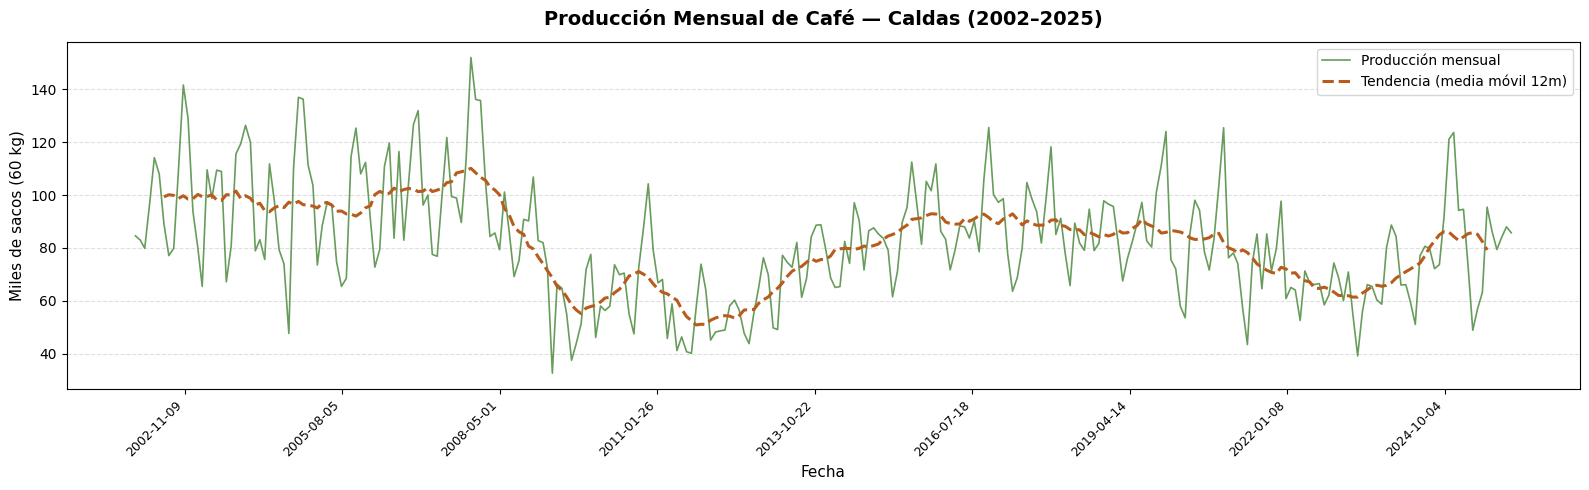

✅ Gráfica guardada → produccion_caldas.png


In [2]:
"""
=============================================================
  CAFÉ SEGURO — Curva de Producción Mensual Caldas
=============================================================
  Prerequisito: haber ejecutado integracion_cafe_seguro.py
  y tener df_cafe en memoria, o cargar cafe_seguro_master.csv
=============================================================
"""

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# ── Cargar dataset maestro si no está en memoria
# df_cafe = pd.read_csv("cafe_seguro_master.csv", parse_dates=["fecha"])

# ─────────────────────────────────────────────
# GRÁFICA: Curva de producción mensual Caldas
# ─────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(16, 5))

ax.plot(
    df_cafe["fecha"],
    df_cafe["prod_caldas_miles_sacos"],
    color="#4E8B3F",
    linewidth=1.2,
    alpha=0.85,
    label="Producción mensual"
)

# Media móvil 12 meses para tendencia
media_movil = df_cafe["prod_caldas_miles_sacos"].rolling(window=12, center=True).mean()
ax.plot(
    df_cafe["fecha"],
    media_movil,
    color="#B85C1E",
    linewidth=2.2,
    linestyle="--",
    label="Tendencia (media móvil 12m)"
)

# Formato de ejes
ax.set_title("Producción Mensual de Café — Caldas (2002–2025)",
             fontsize=14, fontweight="bold", pad=12)
ax.set_xlabel("Fecha", fontsize=11)
ax.set_ylabel("Miles de sacos (60 kg)", fontsize=11)
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
ax.xaxis.set_major_locator(ticker.MaxNLocator(12))
plt.xticks(rotation=45, ha="right", fontsize=9)
ax.grid(axis="y", linestyle="--", alpha=0.4)
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig("produccion_caldas.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Gráfica guardada → produccion_caldas.png")